In [1]:
import sys
sys.path.append("..")

In [2]:
# ==========================================
# CELDA 2: IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import openeo
import logging
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from IPython.display import display
import pandas as pd
import numpy as np
from pipeline.ingesta import *
from pipeline.modulo_vpm import *
from pipeline.modulo_fenologico import *
from config import ROOT

# Configurar un logging básico para ver las advertencias o errores de la API de openEO
logging.basicConfig(level=logging.INFO)

print("✅ Entorno preparado. Librerías importadas correctamente.")

2026-07-06 22:20:49.334 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-06 22:20:49.335 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-06 22:20:49.336 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-06 22:20:49.337 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


✅ Entorno preparado. Librerías importadas correctamente.


In [3]:
#Autenticación con openeo
# openeofed.dataspace.copernicus.eu
# openeo.eodc.eu
print("🔄 Conectando al backend de OpenEO...")
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

INFO:openeo.config:Loaded openEO client config from sources: []


🔄 Conectando al backend de OpenEO...


INFO:openeo.rest.connection:Found OIDC providers: ['CDSE']
INFO:openeo.rest.connection:No OIDC provider given, but only one available: 'CDSE'. Using that one.
INFO:openeo.rest.connection:Using default client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e' from OIDC provider 'CDSE' info.
INFO:openeo.rest.connection:Found refresh token: trying refresh token based authentication.
INFO:openeo.rest.auth.oidc:Doing 'refresh_token' token request 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token' with post data fields ['grant_type', 'client_id', 'refresh_token'] (client_id 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')
INFO:openeo.rest.connection:Obtained tokens: ['access_token', 'id_token', 'refresh_token']
INFO:openeo.rest.auth.config:Storing refresh token for issuer 'https://identity.dataspace.copernicus.eu/auth/realms/CDSE' (client 'sh-b1c3a958-52d4-40fe-a333-153595d1c71e')


Authenticated using refresh token.


In [ ]:
fedconnection = openeo.connect("openeofed.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=VMYG-DNGT 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [5]:
job = connection.job('j-26070703330849faa99be189e1c9a831')
logs = job.logs()

with open("job_logs.txt", "w", encoding="utf-8") as f:
    for entry in logs:
        f.write(f"[{entry['time']}] {entry['level']}: {entry['message']}\n")


In [7]:
# ==========================================
# CARGA DE GEOJSON DE PARCELAS
# ==========================================
import json
import geopandas as gpd

# 1. Ruta de tu archivo GeoJSON en Google Drive
ruta_parcelas = "/content/drive/My Drive/ProyectoTesis/datos_referencia/Datos de Campo Maíz/PoligonosMaizPlayitas.geojson"

print("📂 Cargando parcelas desde Google Drive...")
try:
    gdf_parcelas = gpd.read_file(ruta_parcelas)
    print(f"✅ Archivo cargado con éxito. Total de parcelas: {len(gdf_parcelas)}")
except Exception as e:
    print(f"❌ Error al leer el archivo. Verifica la ruta en tu Drive: {e}")

# 2. Forzar EPSG:4326 estrictamente para el filtro del catálogo de openEO
if gdf_parcelas.crs != "EPSG:4326":
    print("🔄 Reproyectando temporalmente a EPSG:4326 para openEO...")
    gdf_parcelas = gdf_parcelas.to_crs("EPSG:4326")

# Convertir el GeoDataFrame a un diccionario GeoJSON nativo de Python
geojson_openeo = json.loads(gdf_parcelas.to_json())


📂 Cargando parcelas desde Google Drive...
✅ Archivo cargado con éxito. Total de parcelas: 9


In [8]:
# 1. Definir el rango de fechas para el ciclo de maíz (Ejemplo: Campaña de Primera 2025)
temp_ext = ["2022-01-01", "2026-07-05"]

In [ ]:
import numpy as np
import pandas as pd


def extraer_serie_para_sos(
    resultado_preprocesamiento: dict[str, pd.DataFrame],
    id_parcela: str,
    indice: str = "EVI",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Transforma la salida de preprocesar_indices_vpm al formato (serie, fechas)
    que espera detectar_sos, para una parcela y un índice específicos.

    Parámetros
    ----------
    resultado_preprocesamiento : dict[str, pd.DataFrame]
        Salida de preprocesar_indices_vpm. Se espera que cada DataFrame tenga
        índice DatetimeIndex (reindexado diario) y una columna por id_parcela.
    id_parcela : str
        Identificador de la parcela a extraer.
    indice : str, opcional
        "EVI" o "LSWI" (por defecto "EVI").

    Retorna
    -------
    tuple(np.ndarray, np.ndarray)
        (serie, fechas) listos para pasar como argumentos posicionales/keyword
        a detectar_sos. `fechas` son datetime64, ordenados cronológicamente
        ascendente. Pares con NaN en el valor se descartan.

    Lanza
    -----
    KeyError
        Si `indice` no está en resultado_preprocesamiento o `id_parcela` no
        existe como columna.
    ValueError
        Si tras descartar NaN no queda ninguna observación (parcela sin datos
        válidos en el rango solicitado).
    """
    if indice not in resultado_preprocesamiento:
        raise KeyError(
            f"'{indice}' no está en el resultado. Claves disponibles: "
            f"{list(resultado_preprocesamiento.keys())}"
        )

    df = resultado_preprocesamiento[indice]

    if id_parcela not in df.columns:
        raise KeyError(
            f"id_parcela '{id_parcela}' no está en las columnas de '{indice}'."
        )

    col = df[id_parcela].sort_index()

    mascara_validos = col.notna()
    if not mascara_validos.any():
        raise ValueError(
            f"La parcela '{id_parcela}' no tiene observaciones válidas en '{indice}'."
        )

    serie = col.loc[mascara_validos].to_numpy(dtype=float)
    fechas = col.loc[mascara_validos].index.to_numpy(dtype="datetime64[ns]")

    return serie, fechas

In [ ]:
# 2. Cargar únicamente la banda SCL para calcular la máscara morfológica
scl_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=geojson_openeo,
    temporal_extent=temp_ext,
    bands=["SCL"]
)

# Aplicar el proceso nativo de CDSE para expandir máscaras de nubes y sombras
cloud_mask = scl_cube.process(
    "to_scl_dilation_mask",
    data=scl_cube,
    kernel1_size=21, kernel2_size=59,
    mask1_values=[2, 4, 5, 6, 7],
    mask2_values=[3, 8, 9, 10, 11],
    erosion_kernel_size=3)

In [ ]:
print("🛰️ Cargando bandas ópticas para el Modelo VPM (Azul, Rojo, NIR, SWIR)...")

# 3. Cargar las bandas necesarias
datacube_vpm = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=geojson_openeo,
    temporal_extent=temp_ext,
    bands=["B02", "B04", "B08", "B11"]  # B02 (Azul), B04 (Rojo), B08 (NIR), B11 (SWIR)
)

🛰️ Cargando bandas ópticas para el Modelo VPM (Azul, Rojo, NIR, SWIR)...


In [ ]:
# 4. Aplicar la máscara de nubes avanzada y el recorte poligonal estricto
datacube_limpio = datacube_vpm.mask(cloud_mask)
datacube_final = datacube_limpio.mask_polygon(geojson_openeo)

In [ ]:
print("🪄 3. Generando píxeles sintéticos mediante interpolación temporal...")
# Aquí ocurre la magia: openEO rellena cada píxel NaN interpolando con sus vecinos temporales limpios
datacube_interpolado = datacube_final.apply_dimension(
    dimension="t",
    process="array_interpolate_linear"
)

🪄 3. Generando píxeles sintéticos mediante interpolación temporal...


In [11]:
dfs_vpm_crudos = obtener_datacube_indices_crudo(connection, geojson_openeo, temp_ext[0], temp_ext[1])

☁️  1. Generando máscara de nubes (to_scl_dilation_mask) [k1=21, k2=59, erosion=3]...
🛰️  2. Cargando bandas ópticas (B02 Azul, B04 Rojo, B08 NIR, B11 SWIR)...
🪄  3. Interpolando píxeles enmascarados (interpolación lineal temporal)...
🧮  4. Calculando EVI y LSWI...
🔗  5. Fusionando cubos EVI y LSWI...
📊  6. Reducción zonal (media por parcela) en el backend CDSE...
⏳  7. Descargando series temporales a memoria local...
0:00:00 Job 'j-2607061737234898a5ef6b05d5ffb512': send 'start'
0:00:38 Job 'j-2607061737234898a5ef6b05d5ffb512': queued (progress 0%)
0:00:43 Job 'j-2607061737234898a5ef6b05d5ffb512': queued (progress 0%)
0:00:50 Job 'j-2607061737234898a5ef6b05d5ffb512': queued (progress 0%)
0:00:58 Job 'j-2607061737234898a5ef6b05d5ffb512': queued (progress 0%)
0:01:18 Job 'j-2607061737234898a5ef6b05d5ffb512': queued (progress 0%)
0:01:31 Job 'j-2607061737234898a5ef6b05d5ffb512': queued (progress 0%)
0:01:46 Job 'j-2607061737234898a5ef6b05d5ffb512': queued (progress 0%)
0:02:06 Job 'j-260

In [12]:
dict_parametros = preprocesar_indices_vpm(dfs_vpm_crudos)

📈 Suavizando serie temporal para: EVI...
📈 Suavizando serie temporal para: LSWI...

🌾 Calculando FPAR y Factor de Estrés Hídrico Diario (W_scalar)...

✅ Métricas base del VPM calculadas y consolidadas a nivel DIARIO:
   ✔️ Total de Parcelas Procesadas: 9
   ✔️ FPAR Diario (Máx Global): 0.808
   ✔️ W_scalar Diario (Mín/Máx Global): 0.634 / 1.000


In [13]:
serie, fechas = extraer_serie_para_sos(dict_parametros, id_parcela="id_0", indice="EVI")

In [14]:
sos = detectar_sos(
    serie=serie,
    fechas=fechas,
    factor=0.2,
    metodo="seasonal_amplitude",
    ventana_busqueda=(pd.Timestamp("2025-04-01"), pd.Timestamp("2025-04-15")),
)

In [15]:
print(sos)

{'sos_fecha': Timestamp('2025-04-06 00:00:00'), 'sos_valor': np.float64(0.34909649118803776), 'pos_fecha': Timestamp('2025-04-15 00:00:00'), 'pos_valor': np.float64(0.38202919733297175), 'base_valor': 0.3384863327674867, 'amplitud': np.float64(0.04354286456548506), 'umbral': np.float64(0.3471949056805837)}


In [ ]:
print(dict_parametros["W_scalar"])

                id_0      id_1      id_2      id_3      id_4      id_5  \
2025-01-05  0.801648  0.819007  0.779428  1.000000  0.817238  0.843892   
2025-01-06  0.801472  0.818803  0.776149  0.995500  0.817258  0.841953   
2025-01-07  0.801301  0.818607  0.772883  0.991000  0.817268  0.840010   
2025-01-08  0.801141  0.818426  0.769642  0.986500  0.817260  0.838060   
2025-01-09  0.801000  0.818268  0.766437  0.982000  0.817224  0.836097   
...              ...       ...       ...       ...       ...       ...   
2025-12-24  0.805571  0.786441  0.894019  0.773794  0.719033  0.837184   
2025-12-25  0.802140  0.785839  0.894117  0.773528  0.714786  0.834411   
2025-12-26  0.798695  0.785235  0.894217  0.773256  0.710553  0.831640   
2025-12-27  0.795244  0.784632  0.894321  0.772980  0.706328  0.828870   
2025-12-28  0.791790  0.784029  0.894425  0.772704  0.702107  0.826102   

                id_6      id_7      id_8  
2025-01-05  0.835995  0.939399  0.978077  
2025-01-06  0.835435  0.9

In [ ]:
dict_climatico = obtener_datos_climaticos_crudo(fedconnection, geojson_openeo, temp_ext[0], temp_ext[1])

🌍 1. Extrayendo el centroide regional para la grilla climática de AGERA5...
🌍 2. Solicitando cubo de datos al catálogo federado (AGERA5)...
📊 3. Ejecutando reducción espacial sobre el polígono regional GeoJSON...
⏳ 4. Descargando series de tiempo climáticas...
📅 ¡Éxito! Total de fechas recuperadas del servidor federado: 364

✅ Datos climáticos consolidados de forma segura:
   ✔️ Temperatura Media del Dataset: 23.12 °C
   ✔️ Radiación Media del Dataset: 18.97 MJ/m²/día


<>:88: SyntaxWarning: invalid escape sequence '\ '
<>:88: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_983/530374948.py:88: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel("GPP ($g\ C / m^2 / día$)", fontsize=10)


📐 1. Homogeneizando y alineando los horizontes temporales diarios...

✅ ¡Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!
   ✔️ Horizonte temporal continuo evaluado: 358 días.
   ✔️ Temperatura media registrada en la zona: 23.16 °C
   ✔️ GPP Promedio diario del Maíz: 4.481 g C/m²/día
   ✔️ GPP Máximo diario alcanzado: 14.02 g C/m²/día


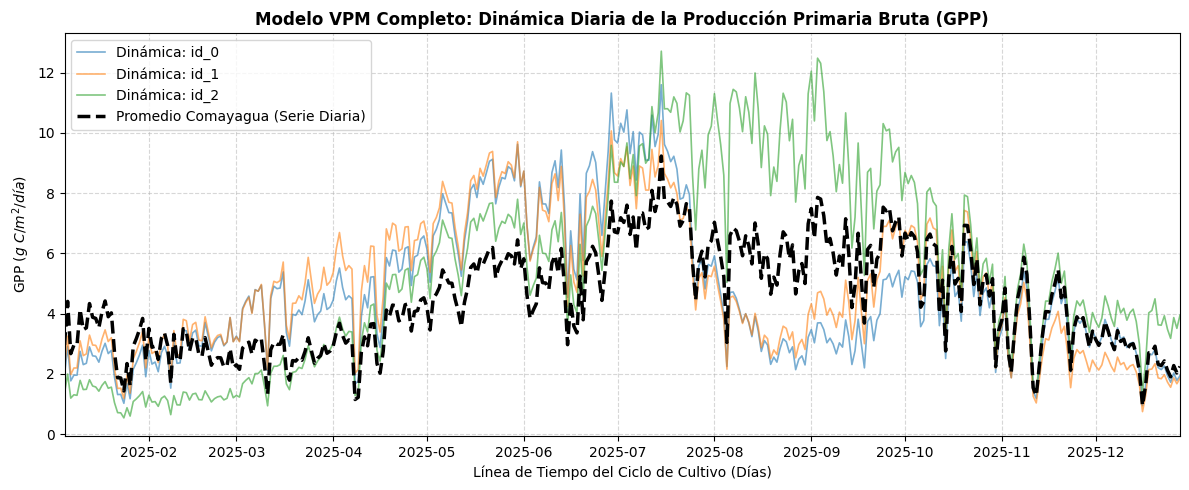

In [ ]:
# =========================================================================
# CELDA: CÁLCULO DE LA PRODUCCIÓN PRIMARIA BRUTA DIARIA CONTINUA (MODELO VPM)
# =========================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("📐 1. Homogeneizando y alineando los horizontes temporales diarios...")
df_t2m = dict_climatico["temperature-mean"]
df_ssrd = dict_climatico["solar-radiation-flux"]

# 1. Asegurar que el clima use el mismo rango temporal diario exacto que la vegetación
df_t2m_diario = df_t2m.reindex(dict_parametros["FPAR"].index, method='nearest')
df_ssrd_diario = df_ssrd.reindex(dict_parametros["FPAR"].index, method='nearest')

# 2. ALINEACIÓN MULTI-PARCELA (Broadcasting de la columna climática regional a todas las parcelas)
# Tomamos la primera columna del clima ('Parcela_1') y la replicamos en la estructura de tus fincas
columnas_parcelas = dict_parametros["FPAR"].columns

df_t2m_aligned = pd.DataFrame(
    np.tile(df_t2m_diario.iloc[:, 0].values, (len(columnas_parcelas), 1)).T,
    index=dict_parametros["FPAR"].index,
    columns=columnas_parcelas
)

df_ssrd_aligned = pd.DataFrame(
    np.tile(df_ssrd_diario.iloc[:, 0].values, (len(columnas_parcelas), 1)).T,
    index=dict_parametros["FPAR"].index,
    columns=columnas_parcelas
)

# --- 3. CONVERSIÓN DE ENERGÍA DIARIA ---
# Convertir J/m²/día a MJ/m²/día (dividido entre 1e6) y extraer el 48% de PAR
df_par = (df_ssrd_aligned / 1e6) * 0.48

# --- 4. CÁLCULO DE T_scalar CON CONDICIONES METEOROLÓGICAS DIARIAS ---
T_min, T_opt, T_max = 10.0, 30.0, 45.0  # Umbrales biológicos C4 (Maíz)

num_t = (df_t2m_aligned - T_min) * (df_t2m_aligned - T_max)
den_t = num_t - ((df_t2m_aligned - T_opt) ** 2)

# Evitar divisiones por cero en el denominador
den_t = den_t.replace(0, np.nan)

df_t_scalar = num_t / den_t
df_t_scalar = df_t_scalar.clip(0.0, 1.0).fillna(0.0)

# Aplicar las restricciones drásticas por frío o estrés térmico por calor
df_t_scalar[df_t2m_aligned < T_min] = 0.0
df_t_scalar[df_t2m_aligned > T_max] = 0.0

# --- 5. CÁLCULO DE LA EFICIENCIA DE USO DE LA LUZ REAL DIARIA (epsilon_g) ---
epsilon_0 = 1.6  # Máxima eficiencia fotosintética teórica para cultivos C4 (Maíz)
df_epsilon = epsilon_0 * df_t_scalar * dict_parametros["W_scalar"]

# --- 6. CÁLCULO DE APAR Y GPP REAL DIARIO ---
df_apar = dict_parametros["FPAR"] * df_par
df_gpp = df_epsilon * df_apar  # Unidad final: g C / m² / día

print("\n✅ ¡Pipeline VPM DIARIO COMPLETADO EXITOSAMENTE!")
print(f"   ✔️ Horizonte temporal continuo evaluado: {df_gpp.shape[0]} días.")
print(f"   ✔️ Temperatura media registrada en la zona: {df_t2m_aligned.mean().mean():.2f} °C")
print(f"   ✔️ GPP Promedio diario del Maíz: {df_gpp.mean().mean():.3f} g C/m²/día")
print(f"   ✔️ GPP Máximo diario alcanzado: {df_gpp.max().max():.2f} g C/m²/día")

# =========================================================================
# GRÁFICA DE CONTROL METODOLÓGICO: EVOLUCIÓN REAL DIARIA
# =========================================================================
plt.figure(figsize=(12, 5))

# Graficar las primeras parcelas para verificar la fluidez diaria continua
max_graficar = min(3, len(df_gpp.columns))
for col in df_gpp.columns[:max_graficar]:
    plt.plot(df_gpp.index, df_gpp[col], linewidth=1.2, alpha=0.6, label=f"Dinámica: {col}")

# Promedio regional masivo en línea negra discontinua (sin marcadores "o" artificiales)
plt.plot(
    df_gpp.index,
    df_gpp.mean(axis=1),
    color='black',
    linewidth=2.5,
    linestyle='--',
    label="Promedio Comayagua (Serie Diaria)"
)

plt.title("Modelo VPM Completo: Dinámica Diaria de la Producción Primaria Bruta (GPP)", fontsize=12, fontweight='bold')
plt.xlabel("Línea de Tiempo del Ciclo de Cultivo (Días)", fontsize=10)
plt.ylabel("GPP ($g\ C / m^2 / día$)", fontsize=10)
plt.xlim(df_gpp.index.min(), df_gpp.index.max())
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# --- El módulo externo recorta tu DataFrame ---
# df_gpp_ciclo = modulo_fenologia.recortar_ciclo(df_gpp, parcela_id)

# --- Invocas tu nueva función reutilizable ---
resultados_produccion = calcular_biomasa_y_rendimiento(
    df_gpp_recortado = df_gpp,
    cue              = 0.56,  # Puedes calibrar estos parámetros por variedad
    harvest_index    = 0.50   # 50% de la planta es grano limpio
)

# Recuperar los objetos resultantes
df_biomasa_dinamica = resultados_produccion["biomasa_acumulada"]
serie_rendimientos  = resultados_produccion["yield_final_tha"]

# Imprimir reporte de rendimiento para tus parcelas en Comayagua
print("🌾 RENDIMIENTOS ESTIMADOS POR PARCELA (t/ha):")
print("-" * 45)
for parcela, valor in serie_rendimientos.items():
    print(f"  🔹 {parcela}: {valor:.2f} toneladas por hectárea")

🌾 RENDIMIENTOS ESTIMADOS POR PARCELA (t/ha):
---------------------------------------------
  🔹 id_0: 10.54 toneladas por hectárea
  🔹 id_1: 10.85 toneladas por hectárea
  🔹 id_2: 12.15 toneladas por hectárea
  🔹 id_3: 9.03 toneladas por hectárea
  🔹 id_4: 12.12 toneladas por hectárea
  🔹 id_5: 7.79 toneladas por hectárea
  🔹 id_6: 5.15 toneladas por hectárea
  🔹 id_7: 10.84 toneladas por hectárea
  🔹 id_8: 11.37 toneladas por hectárea


In [ ]:
df_reporte_final["Area (ha)"] = gdf_parcelas["Area_ha"]
print(df_reporte_final["Area (ha)"])

id_0   NaN
id_1   NaN
id_2   NaN
id_3   NaN
id_4   NaN
id_5   NaN
id_6   NaN
id_7   NaN
id_8   NaN
Name: Area (ha), dtype: float64


In [ ]:
import geopandas as gpd

# 1. Cargar tus parcelas y definir explícitamente que nacen en WGS84 (grados)
gdf_parcelas = gpd.GeoDataFrame.from_features(geojson_openeo["features"], crs="EPSG:4326")

# 2. REGLA DE ORO SIG: Para calcular áreas reales en Honduras (Valle de Comayagua),
# debemos pasar de grados (WGS84 / EPSG:4326) a metros usando la proyección UTM local.
# Para la zona central de Honduras se utiliza UTM Zona 16N (EPSG:32616).
gdf_proyectado = gdf_parcelas.to_crs(epsg=32616)

# 3. Calcular el área en metros cuadrados y convertir a Hectáreas (1 ha = 10,000 m²)
gdf_parcelas["Area_ha"] = gdf_proyectado.geometry.area / 10000.0

# 4. Asignar los nombres de las columnas para alinearlos con tus series temporales ("Parcela_1", "Parcela_2"...)
# Nota: Asegúrate de que el orden coincida exactamente con el de tus funciones previas.
gdf_parcelas["id_pipeline"] = [f"id_{i}" for i in range(len(gdf_parcelas))]
gdf_parcelas.set_index("id_pipeline", inplace=True)

# 5. Recuperar la serie de rendimientos que calculó tu función anterior
# (serie_rendimientos es un pd.Series indexado por "Parcela_1", "Parcela_2"...)
df_reporte_final = pd.DataFrame(serie_rendimientos) # Trae la columna "Yield (t/ha)"

# 6. Unir los datos espaciales con las estimaciones numéricas y calcular PRODUCCIÓN
df_reporte_final["Area (ha)"] = gdf_parcelas["Area_ha"]
df_reporte_final["Produccion_Estimada (t)"] = df_reporte_final["Yield (t/ha)"] * df_reporte_final["Area (ha)"]

# --- Visualizar el Reporte de Producción Final ---
print("🌽 REPORTE CONSOLIDADO DE ESTIMACIÓN DE COSECHA DE MAÍZ:")
print("=" * 60)
print(df_reporte_final[["Area (ha)", "Yield (t/ha)", "Produccion_Estimada (t)"]].round(2))
print("=" * 60)
print(f"🚀 PRODUCCIÓN TOTAL ESTIMADA PARA EL PROYECTO: {df_reporte_final['Produccion_Estimada (t)'].sum():.2f} toneladas.")

🌽 REPORTE CONSOLIDADO DE ESTIMACIÓN DE COSECHA DE MAÍZ:
      Area (ha)  Yield (t/ha)  Produccion_Estimada (t)
id_0       0.10         10.54                     1.07
id_1       0.26         10.85                     2.85
id_2       0.67         12.15                     8.14
id_3       0.36          9.03                     3.22
id_4       2.43         12.12                    29.47
id_5       0.57          7.79                     4.43
id_6       0.64          5.15                     3.29
id_7       4.77         10.84                    51.65
id_8       0.31         11.37                     3.48
🚀 PRODUCCIÓN TOTAL ESTIMADA PARA EL PROYECTO: 107.59 toneladas.


# Visualización y Validación de Datacubes (No forma parte del pipeline de implementación)

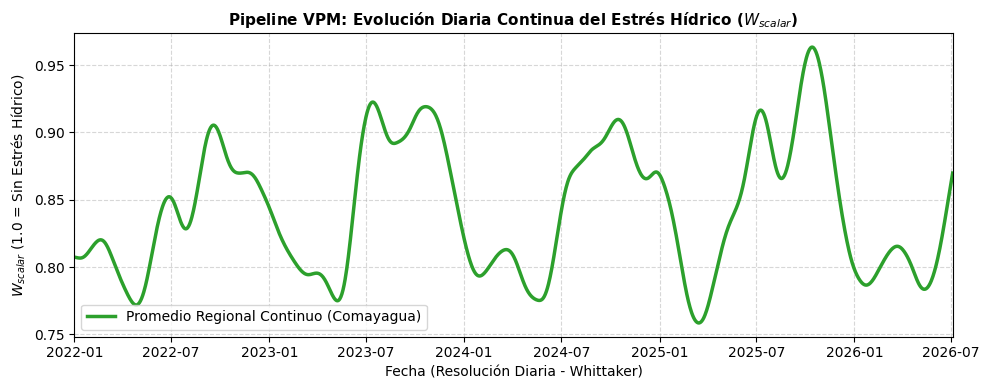

In [16]:

# =========================================================================
# CONTROL DE CALIDAD: Gráfico de verificación rápido del pipeline continuo
# =========================================================================
df_w_scalar = dict_parametros["W_scalar"]
plt.figure(figsize=(10, 4))

# Graficar el promedio de todas las parcelas a lo largo de la serie diaria
plt.plot(
    df_w_scalar.index,
    df_w_scalar.mean(axis=1),
    color='#2ca02c',
    linewidth=2.5,
    label="Promedio Regional Continuo (Comayagua)"
)

plt.title("Pipeline VPM: Evolución Diaria Continua del Estrés Hídrico ($W_{scalar}$)", fontsize=11, fontweight='bold')
plt.xlabel("Fecha (Resolución Diaria - Whittaker)", fontsize=10)
plt.ylabel("$W_{scalar}$ (1.0 = Sin Estrés Hídrico)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(df_w_scalar.index.min(), df_w_scalar.index.max())
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [22]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def graficar_comparativa_whittaker(indice_nombre="EVI"):
    """
    Genera un gráfico interactivo con un dropdown para evaluar el impacto
    del filtro Whittaker parcela por parcela.
    """
    # Extraer los DataFrames correspondientes al índice seleccionado
    df_crudo = dfs_vpm_crudos[indice_nombre]
    df_suave = dict_parametros[indice_nombre]

    # Lista de parcelas disponibles (columnas del DataFrame)
    parcelas = df_crudo.columns.tolist()

    # Definir la función interna que se actualizará con el widget
    def actualizar_grafico(parcela):
        plt.figure(figsize=(12, 5))

        # 1. Graficar la serie suavizada diaria (Línea continua)
        plt.plot(
            df_suave.index,
            df_suave[parcela],
            color='#1f77b4',
            linewidth=2,
            label='Serie Diaria Suavizada (Whittaker)'
        )

        # 2. Graficar los puntos originales de Sentinel-2 (Solo donde NO hay NaN)
        df_puntos_reales = df_crudo[parcela].dropna()
        plt.scatter(
            df_puntos_reales.index,
            df_puntos_reales.values,
            color='#ff7f0e',
            s=45,
            zorder=3,
            label='Adquisiciones Reales S2 (Válidas)'
        )

        # Estética del gráfico
        plt.title(
            f"Control de Calidad Fenológica: {indice_nombre} en {parcela}",
            fontsize=12,
            fontweight='bold',
            pad=10
        )
        plt.xlabel("Fecha del Calendario Agrícola", fontsize=10)
        plt.ylabel(f"Valor del Índice ({indice_nombre})", fontsize=10)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

        # Ajustar límites dinámicos para evitar ruido visual
        plt.xlim(df_suave.index.min(), df_suave.index.max())

        plt.tight_layout()
        plt.show()

    # Crear el menú desplegable interactivo en el notebook
    interact(actualizar_grafico, parcela=widgets.Dropdown(
        options=parcelas,
        value=parcelas[0],
        description='🌱 Parcela:',
        disabled=False,
    ))

# ==========================================
# EJECUCIÓN (Llamar en la celda del notebook)
# ==========================================
graficar_comparativa_whittaker(indice_nombre="EVI")

interactive(children=(Dropdown(description='🌱 Parcela:', options=('id_0', 'id_1', 'id_2', 'id_3', 'id_4', 'id_…

In [25]:
def graficar_comparativa_whittaker2(indice_nombre="EVI", distancia_min_dias=90, prominencia_min=0.15):
    """
    Genera un gráfico interactivo con marcadores verticales punteados
    y sus fechas exactas que delimitan los segmentos fenológicos.
    """
    # Extraer los DataFrames correspondientes al índice seleccionado
    df_crudo = dfs_vpm_crudos[indice_nombre]
    df_suave = dict_parametros[indice_nombre]

    # Lista de parcelas disponibles (columnas del DataFrame)
    parcelas = df_crudo.columns.tolist()

    # Definir la función interna que se actualizará con el widget
    def actualizar_grafico(parcela):
        plt.figure(figsize=(12, 5))

        # 1. Graficar la serie suavizada diaria (Línea continua)
        plt.plot(
            df_suave.index,
            df_suave[parcela],
            color='#1f77b4',
            linewidth=2,
            label='Serie Diaria Suavizada (Whittaker)'
        )

        # 2. Graficar los puntos originales de Sentinel-2 (Solo donde NO hay NaN)
        df_puntos_reales = df_crudo[parcela].dropna()
        plt.scatter(
            df_puntos_reales.index,
            df_puntos_reales.values,
            color='#ff7f0e',
            s=45,
            zorder=3,
            label='Adquisiciones Reales S2 (Válidas)'
        )

        # 3. Calcular y graficar los segmentos (Líneas verticales punteadas)
        serie_parcela = df_suave[parcela]
        segmentos = segmentar_ciclos(serie_parcela, distancia_min_dias, prominencia_min)

        # Obtener los límites del eje Y actuales para posicionar el texto arriba de forma dinámica
        ymin, ymax = plt.gca().get_ylim()
        posicion_y_texto = ymax - (ymax - ymin) * 0.05  # Un 5% por debajo del borde superior

        label_agregado = False
        fechas_etiquetadas = set()  # Para evitar encimar textos en valles compartidos

        for inicio, fin in segmentos:
            # Línea para el inicio del segmento
            plt.axvline(
                x=inicio,
                color='#d62728',
                linestyle=':',
                linewidth=1.8,
                zorder=2,
                label='Límites de Ciclo (Valles)' if not label_agregado else ""
            )
            label_agregado = True

            # Línea para el fin del segmento
            plt.axvline(
                x=fin,
                color='#d62728',
                linestyle=':',
                linewidth=1.8,
                zorder=2
            )

            # Dibujar el texto de la fecha (Formato: AAAA-MM-DD)
            for fecha in (inicio, fin):
                if fecha not in fechas_etiquetadas:
                    plt.text(
                        x=fecha,
                        y=posicion_y_texto,
                        s=fecha.strftime('%Y-%m-%d'),
                        color='#d62728',
                        fontsize=9,
                        fontweight='bold',
                        rotation=90,
                        va='top',           # Alineación vertical superior
                        ha='right',          # Alineación horizontal a la derecha del marcador
                        backgroundcolor=(1, 1, 1, 0.7)  # Fondo blanco semitransparente para legibilidad
                    )
                    fechas_etiquetadas.add(fecha)

        # Estética del gráfico
        plt.title(
            f"Control de Calidad Fenológica y Segmentación: {indice_nombre} en {parcela}",
            fontsize=12,
            fontweight='bold',
            pad=10
        )
        plt.xlabel("Fecha del Calendario Agrícola", fontsize=10)
        plt.ylabel(f"Valor del Índice ({indice_nombre})", fontsize=10)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")

        # Ajustar límites dinámicos para evitar ruido visual
        plt.xlim(df_suave.index.min(), df_suave.index.max())

        plt.tight_layout()
        plt.show()

    # Crear el menú desplegable interactivo en el notebook
    interact(actualizar_grafico, parcela=widgets.Dropdown(
        options=parcelas,
        value=parcelas[0],
        description='🌱 Parcela:',
        disabled=False,
    ))
    # ==========================================
# EJECUCIÓN
# ==========================================
graficar_comparativa_whittaker2(indice_nombre="EVI")

interactive(children=(Dropdown(description='🌱 Parcela:', options=('id_0', 'id_1', 'id_2', 'id_3', 'id_4', 'id_…

In [56]:
serie_parcela = dict_parametros["EVI"]["id_5"]
segmentos = segmentar_ciclos(serie_parcela, 90, 0.15)

In [57]:
serie, fechas = extraer_serie_para_sos(dict_parametros, id_parcela="id_5", indice="EVI")

In [60]:
sos = detectar_sos(
    serie=serie_segmentada,
    fechas=fechas_segmentadas,
    factor=0.2,
    metodo="seasonal_amplitude",
    # ventana_busqueda=(pd.Timestamp("2025-04-01"), pd.Timestamp("2025-04-15")),
)

In [61]:
print(sos)

{'sos_fecha': Timestamp('2024-06-22 00:00:00'), 'sos_valor': np.float64(0.2635363242447753), 'pos_fecha': Timestamp('2024-08-29 00:00:00'), 'pos_valor': np.float64(0.5821781917142351), 'base_valor': 0.18290794785127887, 'amplitud': np.float64(0.3992702438629563), 'umbral': np.float64(0.2627619966238701)}


In [58]:
res = fechas[fechas > segmentos[-1][-1]]

In [59]:
import pandas as pd

# Supongamos que tienes:
# fechas = DatetimeIndex([...])
# serie = np.array([...])  # misma longitud que fechas
# inicio, fin = segmentos[-1]

inicio, fin = segmentos[-1]

# Máscara booleana
mask = (fechas >= inicio) & (fechas <= fin)

# Cortar la serie
serie_segmentada = serie[mask]
fechas_segmentadas = fechas[mask]

print(fechas_segmentadas[:5])
print(serie_segmentada[:5])


DatetimeIndex(['2024-04-14', '2024-04-15', '2024-04-16', '2024-04-17',
               '2024-04-18'],
              dtype='datetime64[ns]', freq='D')
[0.18290795 0.18298303 0.18318045 0.18349784 0.18393285]


In [49]:
print(res)

DatetimeIndex(['2025-03-18', '2025-03-19', '2025-03-20', '2025-03-21',
               '2025-03-22', '2025-03-23', '2025-03-24', '2025-03-25',
               '2025-03-26', '2025-03-27',
               ...
               '2026-06-25', '2026-06-26', '2026-06-27', '2026-06-28',
               '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02',
               '2026-07-03', '2026-07-04'],
              dtype='datetime64[ns]', length=474, freq='D')


In [45]:
segmentos[-1][-1]

Timestamp('2025-03-17 00:00:00')

In [ ]:
# =========================================================
# CELDA A: DESCARGA DE DATOS DESDE OPENEO
# =========================================================

print("📊 1. Enviando peticiones de reducción zonal a openEO...")
# aggregate_spatial procesa el cubo multitemporal sobre tus parcelas
cube_promedios = datacube_indices.aggregate_spatial(
    geometries=geojson_openeo,
    reducer="mean"
)

print("⏳ Descargando datos reducidos a la memoria local de Colab...")
# Ejecutamos y guardamos el diccionario crudo en una variable global
datos_crudos_openeo = cube_promedios.execute()
print("✅ Datos descargados con éxito. Listos para ser procesados en la siguiente celda.")

ERROR:openeo.rest.connection:Preflight process graph validation failed: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


📊 1. Enviando peticiones de reducción zonal a openEO...
⏳ Descargando datos reducidos a la memoria local de Colab...
✅ Datos descargados con éxito. Listos para ser procesados en la siguiente celda.


📈 Graficando 9 parcelas a lo largo de 344 fechas.


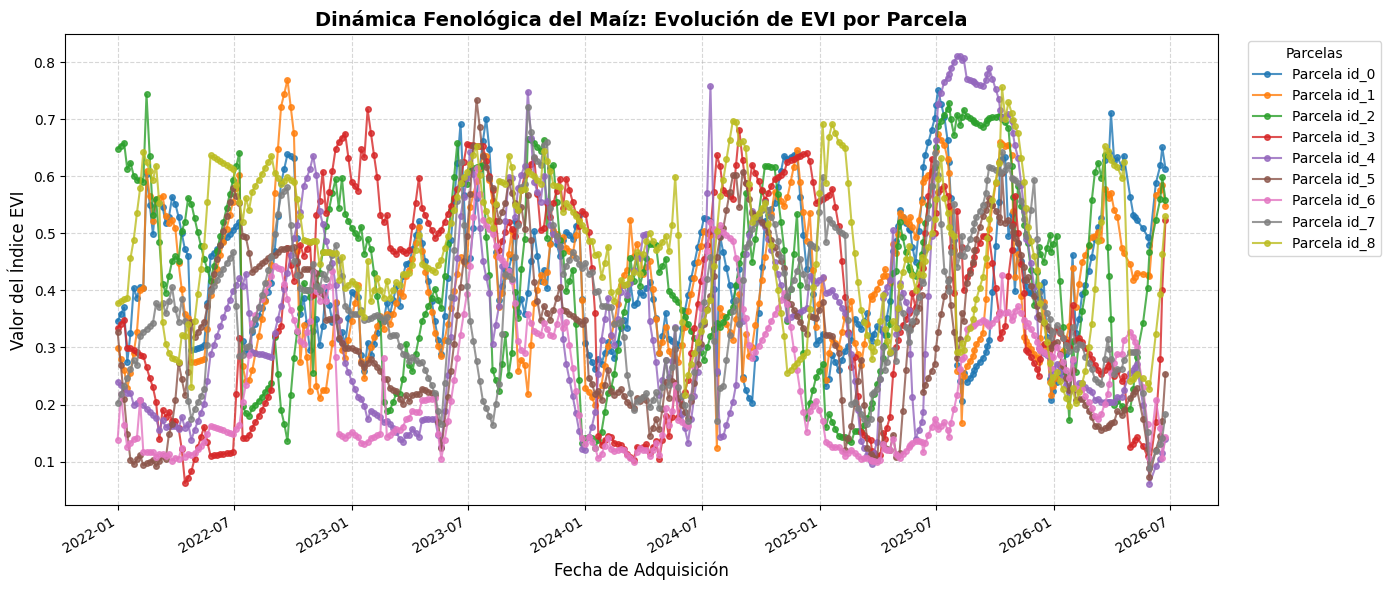

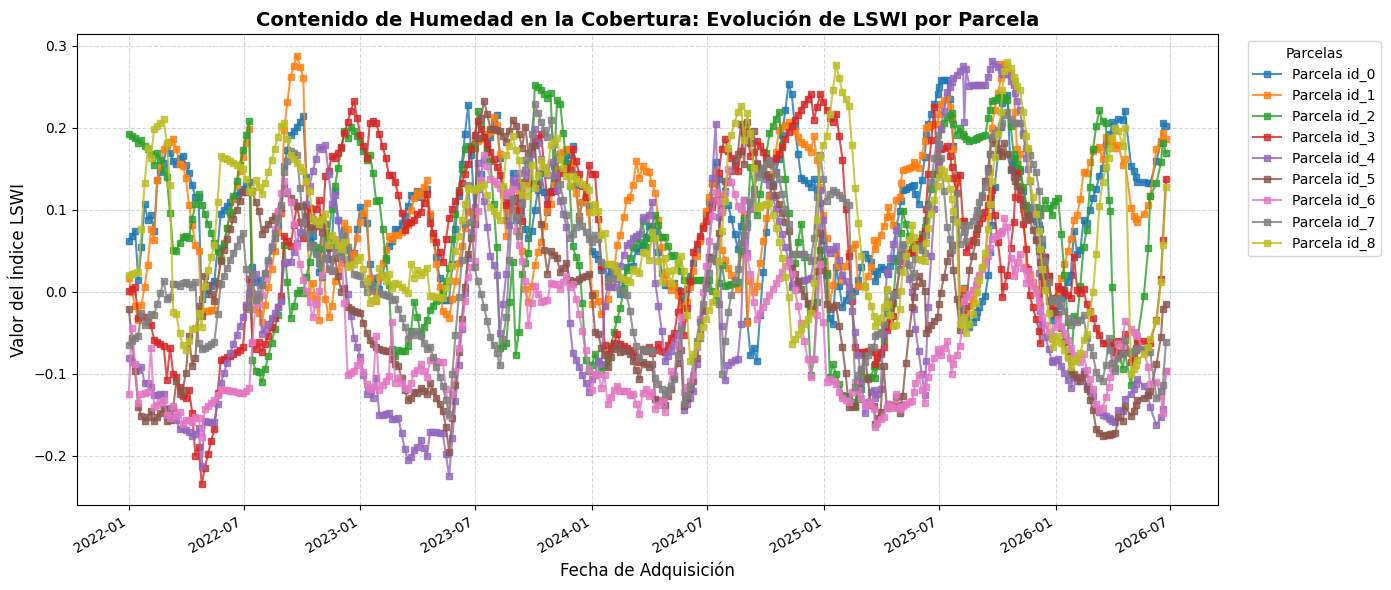

In [31]:
# =========================================================
# CELDA B: PROCESAMIENTO Y GRÁFICA MULTIPARCELA
# =========================================================
import matplotlib.pyplot as plt

# Supongamos que tu función ya devolvió:
# dict_indices = {"EVI": df_evi, "LSWI": df_lswi}
# df_evi = dfs_vpm_crudos["EVI"]
# df_lswi = dfs_vpm_crudos["LSWI"]
df_evi = dfs_vpm_crudos["EVI"]
df_lswi = dfs_vpm_crudos["LSWI"]

num_fechas, num_parcelas = df_evi.shape
print(f"📈 Graficando {num_parcelas} parcelas a lo largo de {num_fechas} fechas.")

# ==========================================
# GRÁFICA 1: EVOLUCIÓN DE EVI POR PARCELA
# ==========================================
plt.figure(figsize=(14, 6))
for col in df_evi.columns:
    plt.plot(
        df_evi.index,
        df_evi[col],
        label=f"Parcela {col}",
        marker="o",
        markersize=4,
        linewidth=1.5,
        alpha=0.8
    )

plt.title("Dinámica Fenológica del Maíz: Evolución de EVI por Parcela", fontsize=14, fontweight="bold")
plt.xlabel("Fecha de Adquisición", fontsize=12)
plt.ylabel("Valor del Índice EVI", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Parcelas")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICA 2: EVOLUCIÓN DE LSWI POR PARCELA
# ==========================================
plt.figure(figsize=(14, 6))
for col in df_lswi.columns:
    plt.plot(
        df_lswi.index,
        df_lswi[col],
        label=f"Parcela {col}",
        marker="s",
        markersize=4,
        linewidth=1.5,
        alpha=0.8
    )

plt.title("Contenido de Humedad en la Cobertura: Evolución de LSWI por Parcela", fontsize=14, fontweight="bold")
plt.xlabel("Fecha de Adquisición", fontsize=12)
plt.ylabel("Valor del Índice LSWI", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Parcelas")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


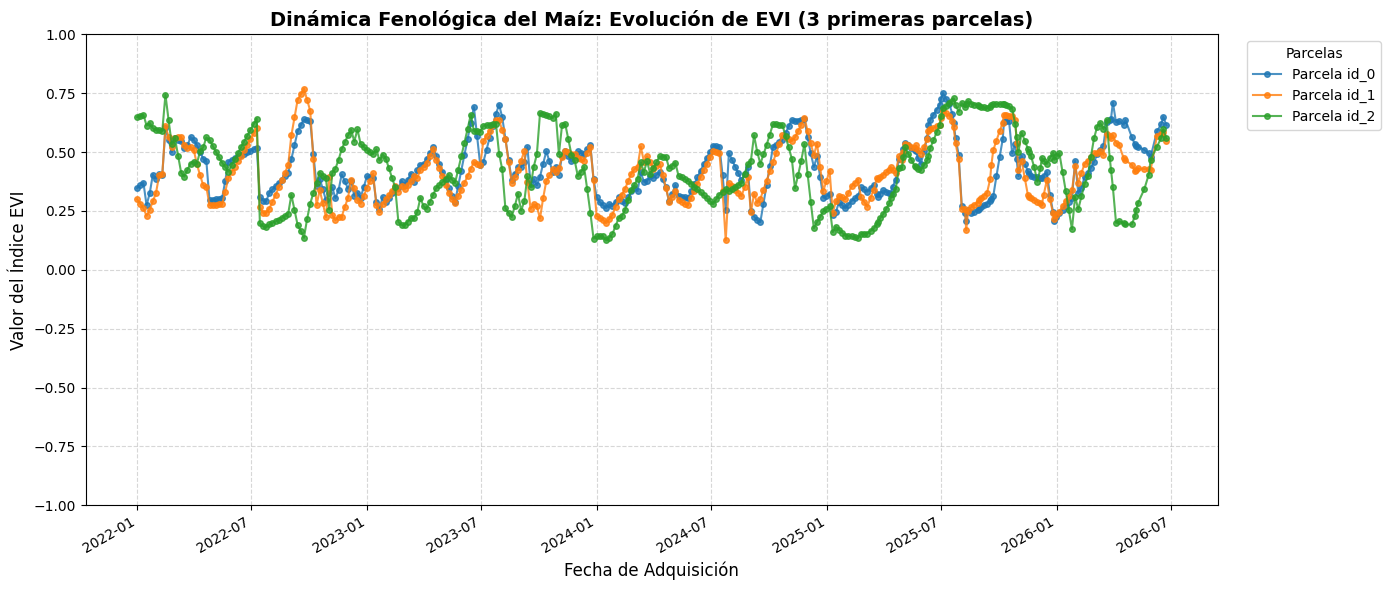

In [32]:
# ==========================================
# GRÁFICA 1: EVOLUCIÓN DE EVI POR PARCELA
# ==========================================
plt.figure(figsize=(14, 6))

# Graficar solo las primeras 3 columnas (parcelas)
for col in df_evi.columns[:3]:
    plt.plot(
        df_evi.index,
        df_evi[col],
        label=f"Parcela {col}",
        marker="o",
        markersize=4,
        linewidth=1.5,
        alpha=0.8
    )

plt.title("Dinámica Fenológica del Maíz: Evolución de EVI (3 primeras parcelas)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha de Adquisición", fontsize=12)
plt.ylabel("Valor del Índice EVI", fontsize=12)
plt.ylim(-1, 1)  # ✅ rango fijo en Y
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Parcelas")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


In [33]:
import plotly.express as px

# Graficar solo las primeras 3 parcelas
df_evi_subset = df_evi.iloc[:, :9]

fig = px.line(
    df_evi_subset,
    x=df_evi_subset.index,
    y=df_evi_subset.columns,
    markers=True,
    labels={"value": "EVI", "variable": "Parcela", "index": "Fecha"},
    title="Dinámica Fenológica del Maíz: Evolución de EVI (3 primeras parcelas)"
)

# Ajustar rango del eje Y
fig.update_yaxes(range=[-1, 1])

# Mostrar gráfico interactivo
fig.show()


In [ ]:
dict_vpm = obtener_datacube_indices_crudo(connection, geojson_openeo, temp_ext[0], temp_ext[1])

☁️  1. Generando máscara de nubes (SCL dilation mask)...
🛰️  2. Cargando bandas ópticas (B02 Azul, B04 Rojo, B08 NIR, B11 SWIR)...
🪄  3. Interpolando píxeles enmascarados (interpolación lineal temporal)...
🧮  4. Calculando EVI y LSWI...
🔗  5. Fusionando cubos EVI y LSWI...
📊  6. Reducción zonal (media por parcela) en el backend CDSE...
⏳  7. Descargando series temporales a memoria local...
🗂️   8. Convirtiendo resultado a DataFrames pandas...
✅  Ingesta completada.


In [ ]:
# =========================================================
# CELDA B: PROCESAMIENTO Y GRÁFICA MULTIPARCELA (formato dict de DataFrames)
# =========================================================
import matplotlib.pyplot as plt

# Extraer los DataFrames del diccionario
df_evi = dict_vpm["EVI"]
df_lswi = dict_vpm["LSWI"]

# Asegurar que el índice sea datetime
df_evi.index = pd.to_datetime(df_evi.index)
df_lswi.index = pd.to_datetime(df_lswi.index)

# Número de parcelas
num_parcelas = df_evi.shape[1]
print(f"📈 Graficando {num_parcelas} parcelas a lo largo de {df_evi.shape[0]} fechas.")

# ==========================================
# GRÁFICA 1: EVOLUCIÓN DE EVI POR PARCELA
# ==========================================
plt.figure(figsize=(14, 6))
for col in df_evi.columns:
    plt.plot(
        df_evi.index,
        df_evi[col],
        label=col,
        marker="o",
        markersize=4,
        linewidth=1.5,
        alpha=0.8
    )

plt.title("Dinámica Fenológica del Maíz: Evolución de EVI por Parcela", fontsize=14, fontweight="bold")
plt.xlabel("Fecha de Adquisición (2025)", fontsize=12)
plt.ylabel("Valor del Índice EVI", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Parcelas")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICA 2: EVOLUCIÓN DE LSWI POR PARCELA
# ==========================================
plt.figure(figsize=(14, 6))
for col in df_lswi.columns:
    plt.plot(
        df_lswi.index,
        df_lswi[col],
        label=col,
        marker="s",
        markersize=4,
        linewidth=1.5,
        alpha=0.8
    )

plt.title("Contenido de Humedad en la Cobertura: Evolución de LSWI por Parcela", fontsize=14, fontweight="bold")
plt.xlabel("Fecha de Adquisición (2025)", fontsize=12)
plt.ylabel("Valor del Índice LSWI", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Parcelas")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


NameError: name 'dict_vpm' is not defined

In [ ]:
datacube_rgb = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=geojson_openeo,
    temporal_extent=temp_ext,
    bands=['B04','B03','B02']
)


In [ ]:
ruta_netcdf = descargar_datacube(datacube_rgb,"datacube_rgb.nc")

⏳ Descargando datos desde openEO a un archivo NetCDF local...
✅ ¡Éxito! Archivo NetCDF descargado y guardado correctamente.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
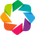

📦 Cargando NetCDF en un xarray.Dataset...


ValueError: did not find a match in any of xarray's currently installed IO backends ['h5netcdf', 'scipy', 'rasterio']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [ ]:
visualizar_banda("datacube_final.nc")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
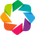

📦 Cargando NetCDF en un xarray.Dataset...
📊 Generando mapa interactivo de la banda B04...


BokehModel(combine_events=True, render_bundle={'docs_json': {'0fd39be1-fb6a-441a-898f-90fdd581af0f': {'version…

BokehModel(combine_events=True, render_bundle={'docs_json': {'3f352872-e016-49b6-ab57-62705b1e62a5': {'version…

In [ ]:
visualizar_banda("datacube_limpio.nc")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
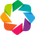

📦 Cargando NetCDF en un xarray.Dataset...
🎨 Normalizando bandas ópticas (Rojo, Verde, Azul)...


BokehModel(combine_events=True, render_bundle={'docs_json': {'9ed78d60-2af0-44b5-b8ce-8adb8e85fdd5': {'version…

BokehModel(combine_events=True, render_bundle={'docs_json': {'33e720e7-822f-48f0-9a43-d686201c39ac': {'version…

In [ ]:
visualizar_rgb(ruta_netcdf)

In [ ]:
import xarray as xr
import numpy as np
import geopandas as gpd
import rioxarray
from shapely.geometry import mapping
import matplotlib.pyplot as plt

ds = xr.open_dataset("cubo_temporal_indices.nc")
evi = ds["EVI"]

# Asignar CRS al xarray (openEO suele entregar en EPSG:32616 o 4326 — ajusta según tu cubo)
evi = evi.rio.write_crs("EPSG:32616")

# Crear una máscara booleana de píxeles dentro de parcelas
# Rasteriza el GeoDataFrame sobre la misma grilla del cubo
mascara_parcelas = evi.isel(t=0).notnull()  # Aproximación: donde hay datos en cualquier fecha

# Forma más precisa: rasterizar el GeoDataFrame directamente
from rasterio.features import geometry_mask
import numpy as np

transform = evi.rio.transform()
ancho = evi.rio.width
alto = evi.rio.height

# gdf_parcelas debe estar en el mismo CRS que el cubo
gdf_reproj = gdf_parcelas.to_crs(evi.rio.crs)

mascara_dentro = ~geometry_mask(
    [mapping(geom) for geom in gdf_reproj.geometry],
    transform=transform,
    invert=False,
    out_shape=(alto, ancho)
)
# mascara_dentro es True donde hay parcela, False en espacio vacío

print(f"Píxeles totales en el cubo:        {mascara_dentro.size:,}")
print(f"Píxeles dentro de parcelas:        {mascara_dentro.sum():,}")
print(f"Cobertura real de parcelas:        {mascara_dentro.mean()*100:.1f}%")
print()

# Ahora calcula NaN rate SOLO dentro de las parcelas
print("Porcentaje de NaN dentro de parcelas por fecha:")
for i, t in enumerate(evi.t.values):
    banda_t = evi.isel(t=i).values          # array 2D numpy
    pixeles_parcela = banda_t[mascara_dentro]
    nan_rate = np.isnan(pixeles_parcela).mean() * 100
    n_validos = (~np.isnan(pixeles_parcela)).sum()
    print(f"  {str(t)[:10]}: {nan_rate:.1f}% NaN  ({n_validos} px válidos)")

Píxeles totales en el cubo:        64,484
Píxeles dentro de parcelas:        1,021
Cobertura real de parcelas:        1.6%

Porcentaje de NaN dentro de parcelas por fecha:
  2025-05-05: 0.0% NaN  (1021 px válidos)
  2025-05-20: 0.0% NaN  (1021 px válidos)
  2025-05-22: 0.0% NaN  (1021 px válidos)
  2025-05-25: 31.9% NaN  (695 px válidos)
  2025-05-30: 0.0% NaN  (1021 px válidos)
  2025-06-09: 0.0% NaN  (1021 px válidos)
  2025-06-11: 0.0% NaN  (1021 px válidos)
  2025-06-24: 21.3% NaN  (804 px válidos)
  2025-06-29: 0.0% NaN  (1021 px válidos)
  2025-07-04: 0.0% NaN  (1021 px válidos)
  2025-07-09: 10.7% NaN  (912 px válidos)
  2025-07-14: 0.0% NaN  (1021 px válidos)
  2025-07-21: 0.0% NaN  (1021 px válidos)
  2025-07-24: 23.9% NaN  (777 px válidos)
  2025-07-29: 11.6% NaN  (903 px válidos)
  2025-08-03: 0.0% NaN  (1021 px válidos)
  2025-08-08: 0.0% NaN  (1021 px válidos)
  2025-08-10: 0.0% NaN  (1021 px válidos)
  2025-08-13: 0.0% NaN  (1021 px válidos)
  2025-08-18: 0.0% NaN  (1021 

In [ ]:
import openeo
import xarray as xr
import numpy as np
import geopandas as gpd
import json
import rioxarray
from rasterio.features import geometry_mask

# ── 1. CONSTRUIR Y DESCARGAR AMBOS CUBOS ─────────────────────────────────────

temp_ext       = ["2025-05-01", "2025-10-31"]
geojson_openeo = json.loads(gdf_parcelas.to_crs("EPSG:4326").to_json())

def construir_scl_mask(connection, geojson, temp_ext):
    scl = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=geojson,
        temporal_extent=temp_ext,
        bands=["SCL"]
    )
    return scl.process(
        "to_scl_dilation_mask", data=scl,
        kernel1_size=17, kernel2_size=77,
        mask1_values=[2, 4, 5, 6, 7],
        mask2_values=[3, 8, 9, 10, 11],
        erosion_kernel_size=3
    )

cloud_mask = construir_scl_mask(connection, geojson_openeo, temp_ext)

datacube_base = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=geojson_openeo,
    temporal_extent=temp_ext,
    bands=["B02"]           # solo B02 para minimizar descarga
).mask(cloud_mask).mask_polygon(geojson_openeo)

# SIN interpolación
cubo_sin = datacube_base

# CON interpolación
cubo_con = datacube_base.apply_dimension(
    dimension="t",
    process="array_interpolate_linear"
)

print("⏳ Descargando cubo SIN interpolación...")
cubo_sin.download("diagnostico_sin_interp.nc", format="NetCDF")
print("✅ Listo: diagnostico_sin_interp.nc")

print("⏳ Descargando cubo CON interpolación...")
cubo_con.download("diagnostico_con_interp.nc", format="NetCDF")
print("✅ Listo: diagnostico_con_interp.nc")

# ── 2. FUNCIÓN DE DIAGNÓSTICO ─────────────────────────────────────────────────

def nan_por_fecha(ruta_nc, gdf_parcelas, label):
    ds  = xr.open_dataset(ruta_nc)
    arr = ds[[v for v in ds.data_vars if v != "crs"][0]]
    dim_t = "t" if "t" in arr.dims else "time"

    arr_rio = arr.rio.write_crs("EPSG:32616").rio.set_spatial_dims(x_dim="x", y_dim="y")
    gdf_utm = gdf_parcelas.to_crs("EPSG:32616")

    mascara = ~geometry_mask(
        [geom.__geo_interface__ for geom in gdf_utm.geometry],
        transform=arr_rio.rio.transform(),
        invert=False,
        out_shape=(arr_rio.rio.height, arr_rio.rio.width)
    )

    resultados = []
    for i, t in enumerate(arr[dim_t].values):
        px       = arr.isel({dim_t: i}).values[mascara]
        nan_rate = np.isnan(px).mean() * 100
        n_val    = (~np.isnan(px)).sum()
        resultados.append((str(t)[:10], nan_rate, n_val))

    print(f"\n{'='*58}")
    print(f"  {label}  |  Px en parcelas: {mascara.sum():,}")
    print(f"{'='*58}")
    print(f"  {'Fecha':<14} {'%NaN':>8} {'Px válidos':>12}  {'Cambio':>8}")
    print(f"  {'-'*50}")
    return resultados, mascara.sum()

# ── 3. COMPARATIVA
res_sin, n_px = nan_por_fecha("diagnostico_sin_interp.nc", gdf_parcelas, "SIN interpolación")
res_con, _    = nan_por_fecha("diagnostico_con_interp.nc", gdf_parcelas, "CON interpolación")

# Alinear por fecha para comparar
dict_sin = {f: (r, v) for f, r, v in res_sin}
dict_con = {f: (r, v) for f, r, v in res_con}
todas_fechas = sorted(set(dict_sin) | set(dict_con))

print(f"\n{'='*65}")
print(f"  COMPARATIVA DIRECTA  |  Px en parcelas: {n_px:,}")
print(f"{'='*65}")
print(f"  {'Fecha':<14} {'SIN %NaN':>10} {'CON %NaN':>10} {'Δ px ganados':>13}")
print(f"  {'-'*53}")

total_ganados = 0
fechas_mejoradas = 0

for fecha in todas_fechas:
    nan_sin, val_sin = dict_sin.get(fecha, (100.0, 0))
    nan_con, val_con = dict_con.get(fecha, (100.0, 0))
    ganados = val_con - val_sin
    total_ganados += max(ganados, 0)
    if ganados > 0:
        fechas_mejoradas += 1
    flag = " ✅" if ganados > 0 else (" ⚠️" if nan_con > 20 else "")
    print(f"  {fecha:<14} {nan_sin:>9.1f}% {nan_con:>9.1f}% {ganados:>+12}{flag}")

print(f"\n  Fechas mejoradas por interpolación: {fechas_mejoradas}/{len(todas_fechas)}")
print(f"  Píxeles-fecha recuperados en total: {total_ganados:,}")
print(f"  Fechas aún con >20% NaN post-interp: "
      f"{sum(1 for f in todas_fechas if dict_con.get(f,(100,0))[0] > 20)}")

⏳ Descargando cubo SIN interpolación...
✅ Listo: diagnostico_sin_interp.nc
⏳ Descargando cubo CON interpolación...
✅ Listo: diagnostico_con_interp.nc

  SIN interpolación  |  Px en parcelas: 1,021
  Fecha              %NaN   Px válidos    Cambio
  --------------------------------------------------

  CON interpolación  |  Px en parcelas: 1,021
  Fecha              %NaN   Px válidos    Cambio
  --------------------------------------------------

  COMPARATIVA DIRECTA  |  Px en parcelas: 1,021
  Fecha            SIN %NaN   CON %NaN  Δ px ganados
  -----------------------------------------------------
  2025-05-05           0.0%       0.0%           +0
  2025-05-20           0.0%       0.0%           +0
  2025-05-22          35.8%       0.0%         +366 ✅
  2025-05-25          96.5%      31.9%         +659 ✅
  2025-05-30           0.0%       0.0%           +0
  2025-06-09          10.7%       0.0%         +109 ✅
  2025-06-11           0.0%       0.0%           +0
  2025-06-24          96